In [1]:
from gsfit_rs.analytic_grad_shafranov.guazzotto_freidberg import Configuration, GuazzottoFreidberg
from gsfit_rs.imas import equilibrium_paths as ep
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# %matplotlib inline
# %matplotlib widget

In [3]:
"""Example 16 - sensor-position uncertainty on the Guazzotto-Freidberg high beta_p lower single null.

The equilibrium, the fitted PF coils and the synthetic magnetics are example 15's: the
up-down asymmetric *lower single-null* tokamak of Guazzotto & Freidberg, J. Plasma Phys. 87
(2021) 905870303 (Figure 9 / Table 3).

Here the magnetic sensors are then randomly perturbed: each is moved by a Gaussian draw, and
each BP probe is also rotated by one, before it takes its measurement. GSFit reconstructs
every perturbed measurement set with the sensors at their *nominal* positions, which is the
experimental situation - the probes are not exactly where the machine description says they
are. The spread of the reconstructed last closed flux surfaces is then the uncertainty that
the sensor-position error alone puts on the boundary.
"""

import math

# --- Dimensionless shape / profile (GF Fig. 9, high beta_p single null) ---
eps = 0.25  # inverse aspect ratio a / r_geo
kappa = 1.8  # upper elongation
delta = 0.6  # upper triangularity
kappa_x = 2.1  # lower X-point elongation
delta_x = 0.8  # lower X-point triangularity
nu = 2.1  # profile parameter (~ poloidal beta)

# --- Dimensional inputs (illustrative; they set the scale, not the shape) ---
r_geo = 1.65  # geometric major radius [metre]
b_vacuum = 2.0  # vacuum toroidal field at r_geo [tesla]
# GF's Table 4 assumes q_0 = 1, which GF Eq. 6.12 gives for beta_0 = 0.0826: an on-axis pressure of 131.5 kPa.
# `p_axis` is the pressure where psi_hat = psi / psi_0 = 1, which is at (x, y) = (0, 0) rather than on the magnetic axis.
# psi_hat = 1.0125 on the magnetic axis, so p_axis = 131.5 kPa / 1.0125 ** 2.
p_axis = 1.283e5  # [pascal]

# --- (R, Z) grid; PF coils are placed on its boundary ---
# Memory in `get_coils` grows as (grid points) x (plasma cells), i.e. as d_grid_gf ** -4: this grid peaks at ~4 GiB
a_minor = eps * r_geo  # minor radius [metre]
z_upper_maximum = kappa * a_minor  # height of the upper maximum [metre]
# The analytic X-point, GF's (x, y) = (-x_X, -kappa_X), is at R = r_geo - a * delta_X (GF Eq. 4.3)
xpt_r = r_geo - a_minor * delta_x  # [metre]
xpt_z = -kappa_x * a_minor  # [metre]
gap_plasma_to_coils_r = 0.20  # [metre]
gap_plasma_to_coils_z = 0.25  # [metre]
# The grid is placed so that Z = 0 is a grid row, so the midplane profiles can be read straight off the grid, and so that the X-point is
# in the middle of a grid cell. The post-processor's boundary tracer looks for the separatrix crossing the edges of the cell holding the
# analytic X-point. The fitted total flux (plasma + coils) puts its X-point a little away from the analytic one, so an X-point near a cell
# edge can leave the separatrix missing that cell's edges, and the tracer then fails.
# Z: the X-point is half way between rows, xpt_z = -(n_z_below_xpt + 1/2) * d_grid_gf, for a grid spacing close to 12 mm
n_z_below_xpt = round(-xpt_z / 0.012 - 0.5)
d_grid_gf = -xpt_z / (n_z_below_xpt + 0.5)  # grid spacing in both R and Z [metre]
n_z_below_midplane = n_z_below_xpt + 1 + math.ceil(gap_plasma_to_coils_z / d_grid_gf)
n_z_above_midplane = math.ceil((z_upper_maximum + gap_plasma_to_coils_z) / d_grid_gf)
n_z = n_z_below_midplane + n_z_above_midplane + 1
z_min = -n_z_below_midplane * d_grid_gf  # [metre]
z_max = n_z_above_midplane * d_grid_gf  # [metre]
# R: the X-point is half way between columns
n_r_inboard_of_xpt = math.ceil((xpt_r - (r_geo - a_minor - gap_plasma_to_coils_r)) / d_grid_gf - 0.5)
r_min = xpt_r - (n_r_inboard_of_xpt + 0.5) * d_grid_gf  # [metre]
n_r = math.ceil((r_geo + a_minor + gap_plasma_to_coils_r - r_min) / d_grid_gf) + 1
r_max = r_min + (n_r - 1) * d_grid_gf  # [metre]

# --- Sensor perturbation (this example) ---
n_perturbed_equilibria = 1_000  # number of perturbed equilibria to reconstruct [dimensionless]
sensor_position_sigma = 3.5e-3  # standard deviation of the perturbation of each sensor's R and Z [metre]
sensor_angle_sigma = np.deg2rad(3.5)  # standard deviation of the perturbation of each BP probe's poloidal orientation [radian]
random_seed = 12345  # so that the perturbations are reproducible
rng = np.random.default_rng(random_seed)

# --- Numerical control ---
n_radial_expansion = 150  # C_n / S_n series length

# 1. Boundary topology + its shape (lower single null: smooth upper half, X-point lower half)
configuration = Configuration.SingleNull(kappa=kappa, delta=delta, kappa_x=kappa_x, delta_x=delta_x)

# 2. Construct the analytic equilibrium
gf = GuazzottoFreidberg(
    configuration,
    eps=eps,
    nu=nu,
    r_geo=r_geo,
    bt_vac_at_r_geo=b_vacuum,
    p_axis=p_axis,
    n_r=n_r,
    n_z=n_z,
    r_min=r_min,
    r_max=r_max,
    z_min=z_min,
    z_max=z_max,
    n_radial_expansion=n_radial_expansion,
)
print(f"GF high beta_p lower single null: eps={eps}, kappa={kappa}, delta={delta}, kappa_x={kappa_x}, delta_x={delta_x}, nu={nu}")
print(f"grid: R in [{r_min:.4f}, {r_max:.4f}] m, Z in [{z_min:.4f}, {z_max:.4f}] m, {n_r}x{n_z}, d_r = d_z = {d_grid_gf * 1.0e3:.3f} mm")
print(f"analytic X-point: R = {xpt_r:.4f} m, Z = {xpt_z:.4f} m")

# 3. Solve the eigenvalue alpha and the normalised flux psi(R, Z)
gf.solve()

GF high beta_p lower single null: eps=0.25, kappa=1.8, delta=0.6, kappa_x=2.1, delta_x=0.8, nu=2.1
grid: R in [1.0273, 2.2699] m, Z in [-1.1231, 1.0037] m, 105x179, d_r = d_z = 11.948 mm
analytic X-point: R = 1.3200 m, Z = -0.8662 m


alpha = 2.089743 (GF Table 4: 2.09);  beta_0 = 0.0806;  bt_diamagnetic_shift = -44.865 mT;  psi_0 = 0.8019 Wb
psi_hat on the magnetic axis = 1.0122 (the grid maximum)


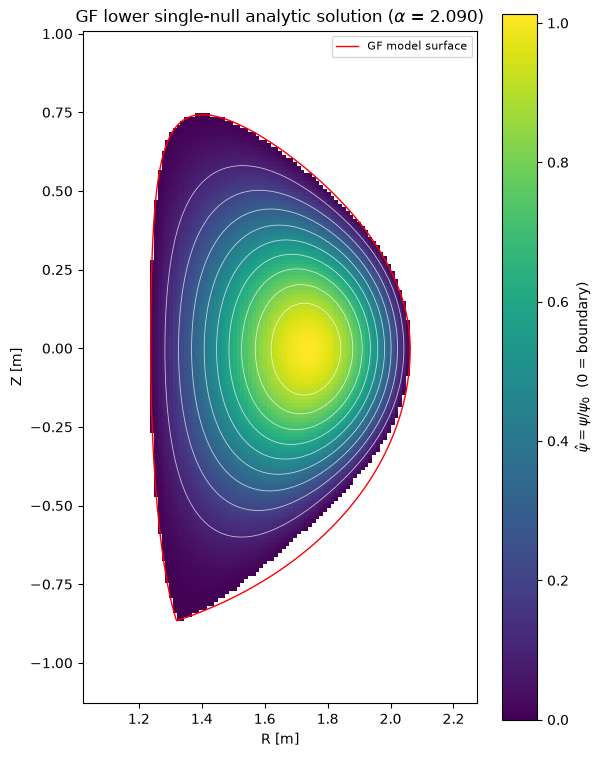

In [4]:
# --- The analytic solution on the (R, Z) grid, with GF's model surface ---
# The equilibrium IDS is only filled once the PF coils are fitted (next cell); until then the
# analytic flux and the plasma mask are what `solve()` provides.
r = np.linspace(gf.r_min, gf.r_max, gf.n_r)
z = np.linspace(gf.z_min, gf.z_max, gf.n_z)
mask = gf.mask  # 1 inside the analytic plasma, 0 elsewhere
# GF's normalised flux: 1 at (x, y) = (0, 0) and 0 on the boundary. NaN outside the plasma, where the
# truncated series is unphysical
psi_hat = np.where(mask > 0, gf.psi_analytic / gf.psi_0, np.nan)
# The model surface: the analytic boundary matches its position, slope and curvature at the inner and outer midplanes,
# the upper maximum and the lower X-point. Elsewhere the analytic boundary is close to it, but not on it.
model_surface_r, model_surface_z = gf.model_surface(n_point_per_half=200)
print(f"alpha = {gf.alpha:.6f} (GF Table 4: 2.09);  beta_0 = {gf.beta_0:.4f};  bt_diamagnetic_shift = {gf.bt_diamagnetic_shift * 1e3:.3f} mT;  psi_0 = {gf.psi_0:.4f} Wb")
print(f"psi_hat on the magnetic axis = {np.nanmax(psi_hat):.4f} (the grid maximum)")

fig, ax = plt.subplots(figsize=(6, 8))
# A pixel plot rather than a filled contour: `contourf` leaves a jagged edge where the plasma meets the NaN outside it.
# `shading="nearest"` centres each pixel on its grid point.
fill = ax.pcolormesh(r, z, psi_hat, vmin=0.0, vmax=np.nanmax(psi_hat), cmap="viridis", shading="nearest")
fig.colorbar(fill, ax=ax, label="$\\hat{\\psi} = \\psi / \\psi_0$  (0 = boundary)")
ax.contour(r, z, psi_hat, levels=np.linspace(0.1, 0.9, 9), colors="white", linewidths=0.6, alpha=0.7)
ax.plot(model_surface_r, model_surface_z, color="red", lw=1.0, label="GF model surface")
ax.set_aspect("equal")
ax.set_xlabel("R [m]")
ax.set_ylabel("Z [m]")
ax.set_title(f"GF lower single-null analytic solution ($\\alpha$ = {gf.alpha:.3f})")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

PF coils (unknowns)                     : 564
plasma grid points constraining the fit : 6588
least squares: 6588 constraints vs 564 unknowns -> OVER-determined
chi^2 of the vacuum flux fit            : 1.443e-09
max fit error / (psi_axis - psi_boundary): 1.534e-04


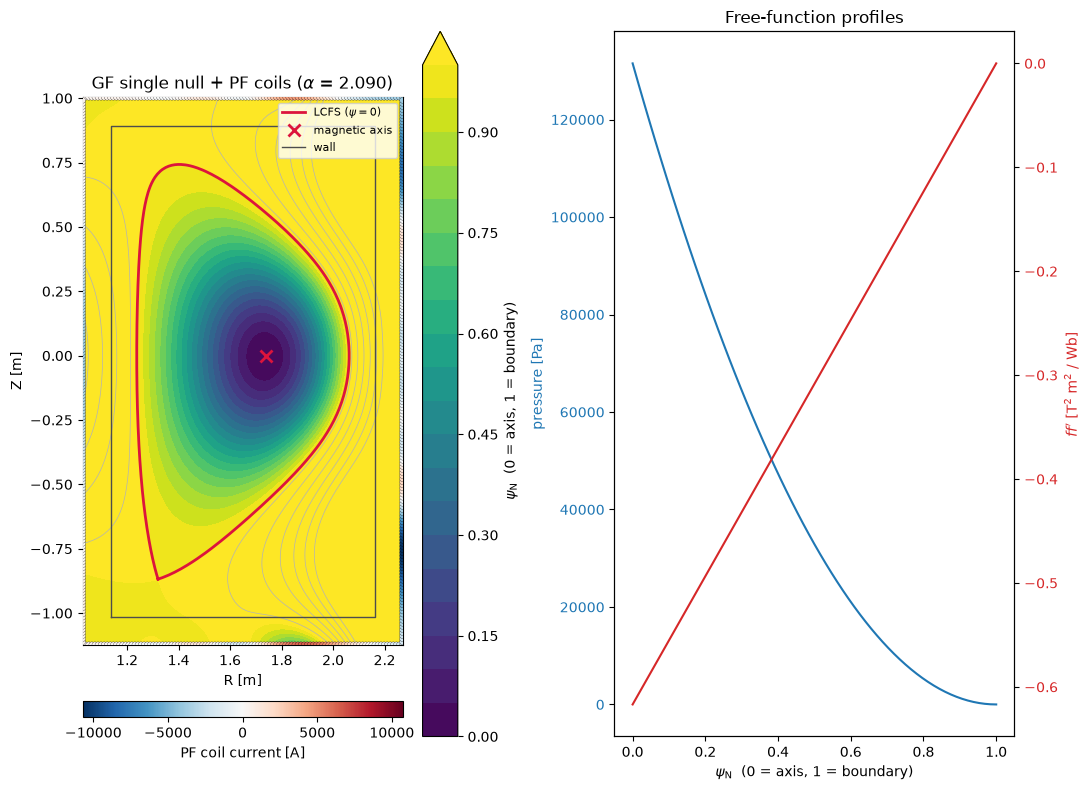

In [5]:
# --- Fit PF coils to reproduce the equilibrium, print the fit determinacy, then plot the free-boundary equilibrium ---
from gsfit_rs import Wall

# Whole-domain control: constrain the total flux at every analytic plasma grid point,
# so the grid points inside the plasma are the least-squares constraints.
mesh_r, mesh_z = np.meshgrid(r, z)  # (n_z, n_r)
control_points = np.column_stack([mesh_r[mask > 0], mesh_z[mask > 0]])

# Wall: a rectangle enclosing the plasma, with extra room below the X-point for the divertor legs. The post-processor traces the
# scrape-off layer legs up to it, and GSFit's reconstruction below uses it as the limiter and vacuum vessel.
# It sits 0.10 m inside the PF coils on every side. `unit(0)` is the vacuum vessel contour; it is the only limiter unit, so it
# also supplies every candidate limit point.
lim_r_lo = r_geo - a_minor - 0.10  # [metre]
lim_r_hi = r_geo + a_minor + 0.10  # [metre]
lim_z_lo = xpt_z - 0.15  # [metre]
lim_z_hi = z_upper_maximum + 0.15  # [metre]
n_side = 60
edge_r = np.linspace(lim_r_lo, lim_r_hi, n_side)
edge_z = np.linspace(lim_z_lo, lim_z_hi, n_side)
limiter_r = np.concatenate([edge_r, np.full(n_side, lim_r_hi), edge_r[::-1], np.full(n_side, lim_r_lo)])
limiter_z = np.concatenate([np.full(n_side, lim_z_lo), edge_z, np.full(n_side, lim_z_hi), edge_z[::-1]])
wall = Wall()
wall.add_limiter_unit(name="vacuum_vessel", r=limiter_r, z=limiter_z)

# Fits the coils, stores the free-boundary equilibrium (plasma + coils) in the IDS, and post-processes it.
# The regularisation is weaker than example 14's 1.0e-6: relative to the plasma size these coils are about twice as far away, so the
# shaping field needs larger coil currents, and 1.0e-6 damps them enough to leave a rippled fit error of about 3e-4 * psi_axis at the
# boundary. At 1.0e-8 what is left is the O(d_grid_gf ** 2) error of representing the plasma current by one filament per grid cell.
gf_coils = gf.get_coils(coil_regularisation_weight=1.0e-8, control_points=control_points, wall=wall)

# --- Read the free-boundary equilibrium back out of the IDS ---
# The flux is the total (plasma + coils), so it is valid in the vacuum as well. The magnetic axis, the
# boundary flux (0) and the X-point are the analytic ones.
gf_equilibrium_ids = gf.equilibrium_ids
psi_total = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi)
psi_axis = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)
psi_boundary = gf_equilibrium_ids.get(ep.time_slice[0].boundary.psi)
# Not masked, unlike `profiles_2d/psi_norm`, so it carries on past 1 into the vacuum
psi_norm_total = (psi_total - psi_axis) / (psi_boundary - psi_axis)
boundary_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
boundary_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)
mag_r = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r)
mag_z = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z)

# One single-filament coil per GF boundary node
gf_coil_names = gf_coils.keys(["pf"])
coil_r = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "r"])[0] for coil_name in gf_coil_names])
coil_z = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "z"])[0] for coil_name in gf_coil_names])
coil_current = np.array([gf_coils.get_array1(["pf", coil_name, "i", "experimental", "value"])[0] for coil_name in gf_coil_names])

# --- Determinacy of the least-squares fit (constraints vs unknowns) ---
n_coil = coil_current.size
n_constraint = control_points.shape[0]
status = "OVER-determined" if n_constraint >= n_coil else "UNDER-determined"
print(f"PF coils (unknowns)                     : {n_coil}")
print(f"plasma grid points constraining the fit : {n_constraint}")
print(f"least squares: {n_constraint} constraints vs {n_coil} unknowns -> {status}")

# --- Quality of the fit: chi^2 of the vacuum flux at the plasma grid points (the control points) ---
# The coils are fitted so that their flux matches the GF vacuum flux, psi_vac^GF = psi^GF - psi_plasma, where psi^GF is the
# analytic flux and psi_plasma is the flux of the GF plasma current. The coil flux is psi_vac^PF.
# chi^2 = 1 / N_plas * sum_k [(psi_vac^GF(R_k, Z_k) - psi_vac^PF(R_k, Z_k)) / (psi_GF,axis - psi_GF,boundary)] ** 2
psi_coils = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi_coils)  # [weber]
psi_plasma = psi_total - psi_coils  # [weber]
psi_vacuum_gf = gf.psi_analytic[mask > 0] - psi_plasma[mask > 0]  # [weber]
psi_vacuum_pf = psi_coils[mask > 0]  # [weber]
chi_sq = np.mean(((psi_vacuum_gf - psi_vacuum_pf) / (psi_axis - psi_boundary)) ** 2)  # [dimensionless]
print(f"chi^2 of the vacuum flux fit            : {chi_sq:.3e}")
fit_error_max = np.max(np.abs(psi_vacuum_gf - psi_vacuum_pf)) / (psi_axis - psi_boundary)  # [dimensionless]
print(f"max fit error / (psi_axis - psi_boundary): {fit_error_max:.3e}")

fig, (ax_flux, ax_profile) = plt.subplots(1, 2, figsize=(11, 8))

# --- Panel 1: total flux surfaces + fitted PF coils ---
fill = ax_flux.contourf(r, z, psi_norm_total, levels=np.linspace(0.0, 1.0, 21), cmap="viridis", extend="max")
fig.colorbar(fill, ax=ax_flux, label="$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
# A few vacuum flux surfaces (psi_N > 1) show the coil-shaped field outside the plasma.
ax_flux.contour(r, z, psi_norm_total, levels=np.linspace(1.05, 1.6, 6), colors="0.7", linewidths=0.5)
ax_flux.plot(boundary_r, boundary_z, color="crimson", lw=2.0, label="LCFS ($\\psi = 0$)")
ax_flux.plot(mag_r, mag_z, "x", color="crimson", ms=9, mew=2, label="magnetic axis")
current_abs_max = np.abs(coil_current).max()
scatter = ax_flux.scatter(
    coil_r,
    coil_z,
    c=coil_current,
    cmap="RdBu_r",
    vmin=-current_abs_max,
    vmax=current_abs_max,
    s=18,
    edgecolors="k",
    linewidths=0.2,
    zorder=5,
)
fig.colorbar(scatter, ax=ax_flux, location="bottom", label="PF coil current [A]", pad=0.08, fraction=0.05)
ax_flux.plot(limiter_r, limiter_z, color="0.3", lw=1.0, label="wall")
ax_flux.set_aspect("equal")
ax_flux.set_xlabel("R [m]")
ax_flux.set_ylabel("Z [m]")
ax_flux.set_title(f"GF single null + PF coils ($\\alpha$ = {gf.alpha:.3f})")
ax_flux.legend(loc="upper right", fontsize=8)

# --- Panel 2: pressure and ff' vs psi_N ---
profile_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)
profile_pressure = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.pressure)
profile_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)
ax_profile.plot(profile_psi_n, profile_pressure, color="tab:blue")
ax_profile.set_xlabel("$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
ax_profile.set_ylabel("pressure [Pa]", color="tab:blue")
ax_profile.tick_params(axis="y", labelcolor="tab:blue")
ax_ff_prime = ax_profile.twinx()
ax_ff_prime.plot(profile_psi_n, profile_ff_prime, color="tab:red")
ax_ff_prime.set_ylabel("$ff'$ [T$^2$ m$^2$ / Wb]", color="tab:red")
ax_ff_prime.tick_params(axis="y", labelcolor="tab:red")
ax_profile.set_title("Free-function profiles")

fig.tight_layout()
plt.show()

Synthetic sensors on the GF equilibrium: 40 flux loops, 42 poloidal BP probes


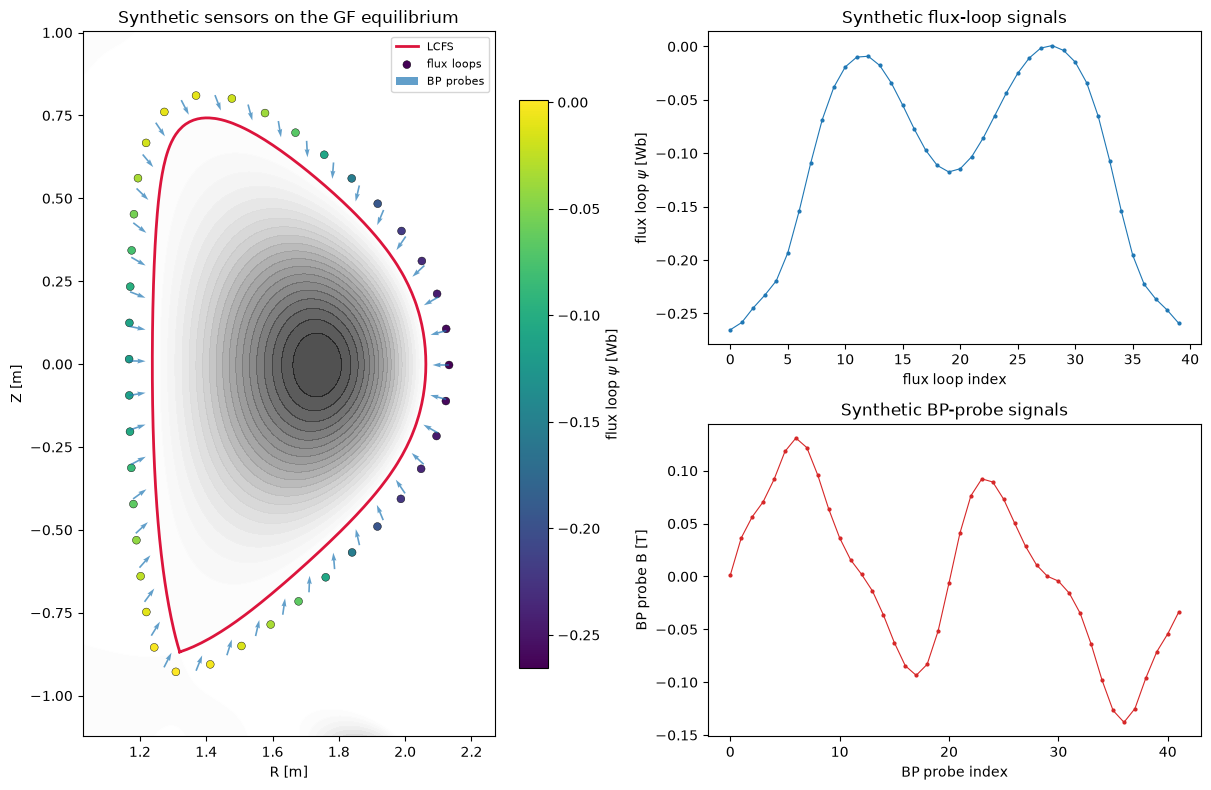

In [6]:
# --- Synthetic magnetic diagnostics from the GF equilibrium ---
# Build a custom sensor set 7 cm outside the plasma: 40 flux loops and 42 BP probes, each set equally spaced by arc length around an outward-offset copy of the free-boundary LCFS.
# Each set starts with a sensor on the low field side midplane. Unlike example 14's double null, a single null is not up/down symmetric, so neither are the sensor sets.
# The BP probes are oriented to point at the magnetic axis. Requires get_coils() above.
import numpy.typing as npt
from gsfit_rs import BpProbes, FluxLoops

sensor_standoff = 0.07  # perpendicular gap between the plasma boundary and the sensors [metre]
n_flux_loop = 40
n_bp_probe = 42

# --- Free-boundary LCFS + magnetic axis from the equilibrium IDS ---
lcfs_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
lcfs_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)
mag_r = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r)
mag_z = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z)


def sensor_ring(
    boundary_r: npt.NDArray[np.float64],
    boundary_z: npt.NDArray[np.float64],
    axis_r: float,
    axis_z: float,
    standoff: float,
    n_sensor: int,
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """
    Place sensors, equally spaced by arc length, on a curve `standoff` outside a closed boundary.

    The curve is the boundary offset along its outward normal (away from the magnetic axis).
    The first sensor is where the curve crosses the midplane, Z = axis_z, on the low field side, and the others follow anticlockwise in (R, Z).

    :param boundary_r: Closed boundary radial positions [metre]
    :param boundary_z: Closed boundary vertical positions [metre]
    :param axis_r: Magnetic axis radial position [metre]
    :param axis_z: Magnetic axis vertical position, which defines the midplane [metre]
    :param standoff: Perpendicular gap between the boundary and the sensors [metre]
    :param n_sensor: Number of sensors
    :return: Sensor radial positions [metre] and vertical positions [metre], each shape (n_sensor,)
    """
    boundary_r = np.asarray(boundary_r, dtype=float)
    boundary_z = np.asarray(boundary_z, dtype=float)
    # Drop a duplicate closing vertex so the loop is not double-counted.
    if np.hypot(boundary_r[0] - boundary_r[-1], boundary_z[0] - boundary_z[-1]) < 1.0e-9:
        boundary_r = boundary_r[:-1]
        boundary_z = boundary_z[:-1]

    # Outward normal at each vertex: rotate the wrapped central-difference tangent by 90 degrees,
    # then flip it to point away from the magnetic axis.
    tangent_r = np.roll(boundary_r, -1) - np.roll(boundary_r, 1)
    tangent_z = np.roll(boundary_z, -1) - np.roll(boundary_z, 1)
    normal_r = tangent_z
    normal_z = -tangent_r
    normal_length = np.maximum(np.hypot(normal_r, normal_z), 1.0e-12)
    normal_r /= normal_length
    normal_z /= normal_length
    pointing_inward = (boundary_r - axis_r) * normal_r + (boundary_z - axis_z) * normal_z < 0.0
    normal_r[pointing_inward] *= -1.0
    normal_z[pointing_inward] *= -1.0

    offset_r = boundary_r + standoff * normal_r
    offset_z = boundary_z + standoff * normal_z

    # Orient the offset curve anticlockwise in (R, Z), from the sign of its shoelace area, so it rises through the low field side midplane
    signed_area = 0.5 * np.sum(offset_r * np.roll(offset_z, -1) - np.roll(offset_r, -1) * offset_z)  # [metre^2]
    if signed_area < 0.0:
        offset_r = offset_r[::-1]
        offset_z = offset_z[::-1]

    # Find the segment on which the curve crosses the midplane upwards, on the low field side.
    # A vertex exactly on the midplane belongs to only one crossing segment, as the comparisons are strict on one side.
    n_vertex = offset_r.size
    i_vertex_low_field_side_list = []
    for i_vertex in range(n_vertex):
        i_vertex_next = (i_vertex + 1) % n_vertex
        if offset_z[i_vertex] < axis_z <= offset_z[i_vertex_next] and offset_r[i_vertex] > axis_r:
            i_vertex_low_field_side_list.append(i_vertex)
    if len(i_vertex_low_field_side_list) != 1:
        raise ValueError(f"the offset curve must cross the low field side midplane once; found {len(i_vertex_low_field_side_list)} crossings")
    i_vertex_low_field_side = i_vertex_low_field_side_list[0]

    # The curve, reordered to run once around from the low field side midplane crossing back to it
    i_vertex_next = (i_vertex_low_field_side + 1) % n_vertex
    fraction = (axis_z - offset_z[i_vertex_low_field_side]) / (offset_z[i_vertex_next] - offset_z[i_vertex_low_field_side])  # [dimensionless]
    crossing_r = offset_r[i_vertex_low_field_side] + fraction * (offset_r[i_vertex_next] - offset_r[i_vertex_low_field_side])  # [metre]
    loop_r = np.full(n_vertex + 2, np.nan)  # [metre]
    loop_z = np.full(n_vertex + 2, np.nan)  # [metre]
    loop_r[0] = crossing_r
    loop_z[0] = axis_z
    for i_loop_vertex in range(n_vertex):
        i_vertex = (i_vertex_low_field_side + 1 + i_loop_vertex) % n_vertex
        loop_r[i_loop_vertex + 1] = offset_r[i_vertex]
        loop_z[i_loop_vertex + 1] = offset_z[i_vertex]
    loop_r[-1] = crossing_r
    loop_z[-1] = axis_z

    # Sample at equal arc length; the end of the loop is its start, so it is not sampled twice
    arc_length = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(loop_r), np.diff(loop_z)))])  # [metre]
    sample_arc_length = np.linspace(0.0, arc_length[-1], n_sensor, endpoint=False)  # [metre]
    sensor_r = np.interp(sample_arc_length, arc_length, loop_r)  # [metre]
    sensor_z = np.interp(sample_arc_length, arc_length, loop_z)  # [metre]
    return sensor_r, sensor_z


flux_loop_r, flux_loop_z = sensor_ring(lcfs_r, lcfs_z, mag_r, mag_z, sensor_standoff, n_flux_loop)
bp_probe_r, bp_probe_z = sensor_ring(lcfs_r, lcfs_z, mag_r, mag_z, sensor_standoff, n_bp_probe)
# Orient each BP probe towards the magnetic axis: B_probe = B_r cos(angle_pol) + B_z sin(angle_pol).
bp_probe_angle = np.arctan2(mag_z - bp_probe_z, mag_r - bp_probe_r)

placeholder_measured = np.array([np.nan])  # overwritten by get_sensor_values
placeholder_time = np.array([0.0])

flux_loops = FluxLoops()
for i_flux_loop in range(n_flux_loop):
    flux_loops.add_sensor(
        f"FL_{i_flux_loop:02d}",
        float(flux_loop_r[i_flux_loop]),  # R [metre]
        float(flux_loop_z[i_flux_loop]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        placeholder_time,
        placeholder_measured,
    )

bp_probes = BpProbes()
for i_bp_probe in range(n_bp_probe):
    bp_probes.add_sensor(
        f"BP_{i_bp_probe:02d}",
        float(bp_probe_angle[i_bp_probe]),  # poloidal orientation [radian]
        float(bp_probe_r[i_bp_probe]),  # R [metre]
        float(bp_probe_z[i_bp_probe]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        placeholder_time,
        placeholder_measured,
    )

# Fill the (NaN) measurements from the GF plasma + fitted coils (mutates both sensor objects).
gf.get_sensor_values(bp_probes, flux_loops, gf_coils)

# --- Read the synthetic signals back ---
flux_loop_names = flux_loops.keys()
flux_loop_r = np.array([flux_loops.get_f64([name, "geometry", "r"]) for name in flux_loop_names])
flux_loop_z = np.array([flux_loops.get_f64([name, "geometry", "z"]) for name in flux_loop_names])
flux_loop_psi = np.array([flux_loops.get_array1([name, "psi", "experimental", "value"])[0] for name in flux_loop_names])

bp_probe_names = bp_probes.keys()
bp_probe_r = np.array([bp_probes.get_f64([name, "geometry", "r"]) for name in bp_probe_names])
bp_probe_z = np.array([bp_probes.get_f64([name, "geometry", "z"]) for name in bp_probe_names])
bp_probe_angle = np.array([bp_probes.get_f64([name, "geometry", "angle_pol"]) for name in bp_probe_names])
bp_probe_b = np.array([bp_probes.get_array1([name, "b", "experimental", "value"])[0] for name in bp_probe_names])
print(f"Synthetic sensors on the GF equilibrium: {flux_loop_psi.size} flux loops, {bp_probe_b.size} poloidal BP probes")

# --- Plot: sensor map (left) + synthetic signals (right) ---
fig = plt.figure(figsize=(13, 8))
grid_spec = fig.add_gridspec(2, 2, width_ratios=[1.25, 1.0])
ax_map = fig.add_subplot(grid_spec[:, 0])
ax_flux_loop = fig.add_subplot(grid_spec[0, 1])
ax_bp_probe = fig.add_subplot(grid_spec[1, 1])

ax_map.contourf(r, z, psi_norm_total, levels=np.linspace(0.0, 1.0, 21), cmap="Greys_r", extend="max", alpha=0.7)
ax_map.plot(lcfs_r, lcfs_z, color="crimson", lw=2.0, label="LCFS")
loop_scatter = ax_map.scatter(flux_loop_r, flux_loop_z, c=flux_loop_psi, cmap="viridis", s=32, edgecolors="k", linewidths=0.3, zorder=4, label="flux loops")
fig.colorbar(loop_scatter, ax=ax_map, label="flux loop $\\psi$ [Wb]", fraction=0.046, pad=0.04)
# BP probes: location + poloidal orientation arrow (pointing at the magnetic axis).
ax_map.quiver(
    bp_probe_r, bp_probe_z, np.cos(bp_probe_angle), np.sin(bp_probe_angle), color="tab:blue", scale=25, width=0.004, alpha=0.7, zorder=5, label="BP probes"
)
ax_map.set_aspect("equal")
ax_map.set_xlabel("R [m]")
ax_map.set_ylabel("Z [m]")
ax_map.set_title("Synthetic sensors on the GF equilibrium")
ax_map.legend(loc="upper right", fontsize=8)

ax_flux_loop.plot(flux_loop_psi, ".-", color="tab:blue", lw=0.8, ms=4)
ax_flux_loop.set_ylabel("flux loop $\\psi$ [Wb]")
ax_flux_loop.set_xlabel("flux loop index")
ax_flux_loop.set_title("Synthetic flux-loop signals")

ax_bp_probe.plot(bp_probe_b, ".-", color="tab:red", lw=0.8, ms=4)
ax_bp_probe.set_ylabel("BP probe B [T]")
ax_bp_probe.set_xlabel("BP probe index")
ax_bp_probe.set_title("Synthetic BP-probe signals")

fig.tight_layout()
plt.show()

1000 perturbed measurement sets; sensor position sigma = 3.5 mm, BP probe angle sigma = 3.5 deg
flux loops: rms shift = 6.730e-03 Wb (2.53% of the signal span)
BP probes : rms shift = 9.374e-03 T  (3.49% of the signal span)


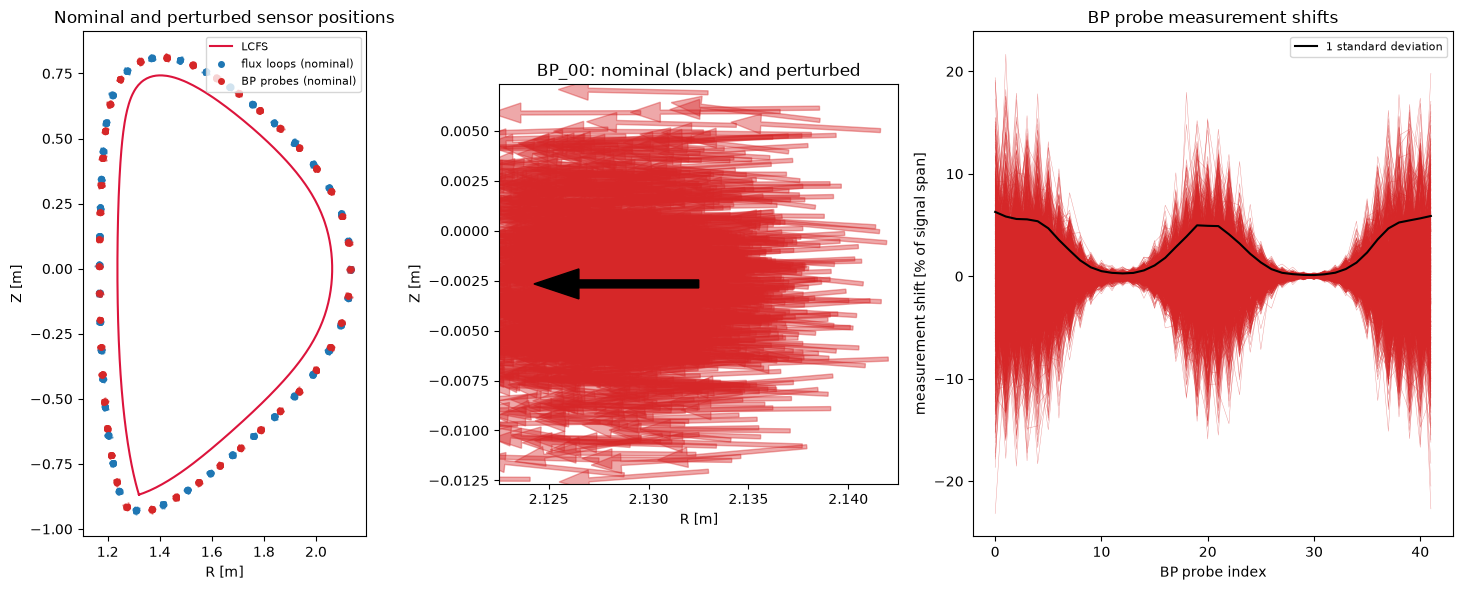

In [7]:
# --- Perturb the sensors, and take a synthetic measurement set with each perturbation ---
# Each sensor is moved by a Gaussian draw of standard deviation `sensor_position_sigma` in R and in Z, and each BP probe is
# additionally rotated by a draw of standard deviation `sensor_angle_sigma`. The sensor then measures the GF field where it
# actually is. The reconstruction below places the sensors at their nominal positions, so what is being modelled is the
# experimental situation: the probe is not exactly where the machine description says it is.
#
# Slice 0 is the unperturbed measurement set, so the reconstruction of it is the reference for the perturbed ones.
n_slice = n_perturbed_equilibria + 1
# GSFit reconstructs a time-slice per "time", and solves the slices in parallel, so the perturbations are run as a timebase
slice_time = np.arange(n_slice, dtype=float)  # [second]

flux_loop_psi_perturbed = np.full((n_slice, n_flux_loop), np.nan)  # [weber]
bp_probe_b_perturbed = np.full((n_slice, n_bp_probe), np.nan)  # [tesla]
# The perturbed sensor geometry of every slice, kept for the figure below
flux_loop_r_perturbed = np.full((n_slice, n_flux_loop), np.nan)  # [metre]
flux_loop_z_perturbed = np.full((n_slice, n_flux_loop), np.nan)  # [metre]
bp_probe_r_perturbed = np.full((n_slice, n_bp_probe), np.nan)  # [metre]
bp_probe_z_perturbed = np.full((n_slice, n_bp_probe), np.nan)  # [metre]
bp_probe_angle_perturbed = np.full((n_slice, n_bp_probe), np.nan)  # [radian]

for i_slice in range(n_slice):
    # Slice 0 is unperturbed; every other slice draws its own sensor positions
    if i_slice == 0:
        flux_loop_r_perturbed[i_slice, :] = flux_loop_r
        flux_loop_z_perturbed[i_slice, :] = flux_loop_z
        bp_probe_r_perturbed[i_slice, :] = bp_probe_r
        bp_probe_z_perturbed[i_slice, :] = bp_probe_z
        bp_probe_angle_perturbed[i_slice, :] = bp_probe_angle
    else:
        flux_loop_r_perturbed[i_slice, :] = rng.normal(flux_loop_r, sensor_position_sigma)
        flux_loop_z_perturbed[i_slice, :] = rng.normal(flux_loop_z, sensor_position_sigma)
        bp_probe_r_perturbed[i_slice, :] = rng.normal(bp_probe_r, sensor_position_sigma)
        bp_probe_z_perturbed[i_slice, :] = rng.normal(bp_probe_z, sensor_position_sigma)
        bp_probe_angle_perturbed[i_slice, :] = rng.normal(bp_probe_angle, sensor_angle_sigma)

    # Sensors at the perturbed geometry, purely to measure the GF field there
    flux_loops_at_perturbed_geometry = FluxLoops()
    for i_flux_loop in range(n_flux_loop):
        flux_loops_at_perturbed_geometry.add_sensor(
            f"FL_{i_flux_loop:02d}",
            float(flux_loop_r_perturbed[i_slice, i_flux_loop]),  # R [metre]
            float(flux_loop_z_perturbed[i_slice, i_flux_loop]),  # Z [metre]
            "",  # fit comment
            1.0,  # expected value
            True,  # include in fit
            1.0,  # weight
            placeholder_time,
            placeholder_measured,
        )
    bp_probes_at_perturbed_geometry = BpProbes()
    for i_bp_probe in range(n_bp_probe):
        bp_probes_at_perturbed_geometry.add_sensor(
            f"BP_{i_bp_probe:02d}",
            float(bp_probe_angle_perturbed[i_slice, i_bp_probe]),  # poloidal orientation [radian]
            float(bp_probe_r_perturbed[i_slice, i_bp_probe]),  # R [metre]
            float(bp_probe_z_perturbed[i_slice, i_bp_probe]),  # Z [metre]
            "",  # fit comment
            1.0,  # expected value
            True,  # include in fit
            1.0,  # weight
            placeholder_time,
            placeholder_measured,
        )

    gf.get_sensor_values(bp_probes_at_perturbed_geometry, flux_loops_at_perturbed_geometry, gf_coils)

    for i_flux_loop in range(n_flux_loop):
        flux_loop_psi_perturbed[i_slice, i_flux_loop] = flux_loops_at_perturbed_geometry.get_array1([f"FL_{i_flux_loop:02d}", "psi", "experimental", "value"])[0]
    for i_bp_probe in range(n_bp_probe):
        bp_probe_b_perturbed[i_slice, i_bp_probe] = bp_probes_at_perturbed_geometry.get_array1([f"BP_{i_bp_probe:02d}", "b", "experimental", "value"])[0]

# How much the perturbation moves each measurement, relative to the range of that sensor set
flux_loop_shift = flux_loop_psi_perturbed[1:, :] - flux_loop_psi_perturbed[0, :]  # [weber]
bp_probe_shift = bp_probe_b_perturbed[1:, :] - bp_probe_b_perturbed[0, :]  # [tesla]
flux_loop_span = flux_loop_psi_perturbed[0, :].max() - flux_loop_psi_perturbed[0, :].min()  # [weber]
bp_probe_span = bp_probe_b_perturbed[0, :].max() - bp_probe_b_perturbed[0, :].min()  # [tesla]
print(f"{n_perturbed_equilibria} perturbed measurement sets; sensor position sigma = {sensor_position_sigma * 1.0e3:.1f} mm, BP probe angle sigma = {np.rad2deg(sensor_angle_sigma):.1f} deg")
print(f"flux loops: rms shift = {np.sqrt(np.mean(flux_loop_shift ** 2)):.3e} Wb ({100 * np.sqrt(np.mean(flux_loop_shift ** 2)) / flux_loop_span:.2f}% of the signal span)")
print(f"BP probes : rms shift = {np.sqrt(np.mean(bp_probe_shift ** 2)):.3e} T  ({100 * np.sqrt(np.mean(bp_probe_shift ** 2)) / bp_probe_span:.2f}% of the signal span)")

fig, (ax_map, ax_zoom, ax_shift) = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={"width_ratios": [1.0, 1.0, 1.2]})

# --- Panel 1: where the sensors are, nominal and perturbed ---
ax_map.plot(boundary_r, boundary_z, color="crimson", lw=1.5, label="LCFS")
ax_map.plot(flux_loop_r_perturbed[1:, :], flux_loop_z_perturbed[1:, :], ".", color="tab:blue", ms=1.5, alpha=0.5)
ax_map.plot(bp_probe_r_perturbed[1:, :], bp_probe_z_perturbed[1:, :], ".", color="tab:red", ms=1.5, alpha=0.5)
ax_map.plot(flux_loop_r, flux_loop_z, "o", color="tab:blue", ms=4, label="flux loops (nominal)")
ax_map.plot(bp_probe_r, bp_probe_z, "o", color="tab:red", ms=4, label="BP probes (nominal)")
ax_map.set_aspect("equal")
ax_map.set_xlabel("R [m]")
ax_map.set_ylabel("Z [m]")
ax_map.set_title("Nominal and perturbed sensor positions")
ax_map.legend(loc="upper right", fontsize=8)

# --- Panel 2: one BP probe close up, with its orientation ---
i_bp_probe_zoom = 0
arrow_length = 0.006  # [metre]
zoom_half_width = 0.010  # [metre]
for i_slice in range(1, n_slice):
    ax_zoom.arrow(
        bp_probe_r_perturbed[i_slice, i_bp_probe_zoom],
        bp_probe_z_perturbed[i_slice, i_bp_probe_zoom],
        arrow_length * np.cos(bp_probe_angle_perturbed[i_slice, i_bp_probe_zoom]),
        arrow_length * np.sin(bp_probe_angle_perturbed[i_slice, i_bp_probe_zoom]),
        color="tab:red",
        alpha=0.4,
        width=0.0002,
        head_width=0.001,
    )
ax_zoom.arrow(
    bp_probe_r[i_bp_probe_zoom],
    bp_probe_z[i_bp_probe_zoom],
    arrow_length * np.cos(bp_probe_angle[i_bp_probe_zoom]),
    arrow_length * np.sin(bp_probe_angle[i_bp_probe_zoom]),
    color="k",
    width=0.0004,
    head_width=0.0015,
)
ax_zoom.set_aspect("equal")
ax_zoom.set_xlim(bp_probe_r[i_bp_probe_zoom] - zoom_half_width, bp_probe_r[i_bp_probe_zoom] + zoom_half_width)
ax_zoom.set_ylim(bp_probe_z[i_bp_probe_zoom] - zoom_half_width, bp_probe_z[i_bp_probe_zoom] + zoom_half_width)
ax_zoom.locator_params(axis="x", nbins=4)
ax_zoom.set_xlabel("R [m]")
ax_zoom.set_ylabel("Z [m]")
ax_zoom.set_title(f"BP_{i_bp_probe_zoom:02d}: nominal (black) and perturbed")

# --- Panel 3: the spread each perturbation puts on the measurements ---
ax_shift.plot(np.arange(n_bp_probe), 100.0 * bp_probe_shift.T / bp_probe_span, color="tab:red", lw=0.3, alpha=0.5)
ax_shift.plot(np.arange(n_bp_probe), 100.0 * np.std(bp_probe_shift, axis=0) / bp_probe_span, color="k", lw=1.5, label="1 standard deviation")
ax_shift.set_xlabel("BP probe index")
ax_shift.set_ylabel("measurement shift [% of signal span]")
ax_shift.set_title("BP probe measurement shifts")
ax_shift.legend(fontsize=8)

fig.tight_layout()
plt.show()

In [8]:
# --- Reconstruct every perturbed measurement set with GSFit, with the sensors at their NOMINAL positions ---
# The perturbed measurement sets are handed to GSFit as a timebase, one "time" per perturbation, and GSFit solves the
# time-slices in parallel. Slice 0 is the unperturbed set.
import time as time_py

import gsfit_rs
from gsfit_rs import Coils, Dialoop, Isoflux, IsofluxBoundary, Passives, Plasma, Pressure, RogowskiCoils, StationaryPoint, Tf, solve_grad_shafranov

ip_gf = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.ip)
print(f"GF plasma current (seed): {ip_gf / 1.0e3:.1f} kA;  magnetic axis R = {mag_r:.3f} m, Z = {mag_z:.4f} m")

# --- Sensors at their nominal geometry, carrying the perturbed measurements ---
flux_loops = FluxLoops()
for i_flux_loop in range(n_flux_loop):
    flux_loops.add_sensor(
        f"FL_{i_flux_loop:02d}",
        float(flux_loop_r[i_flux_loop]),  # R [metre]
        float(flux_loop_z[i_flux_loop]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        slice_time,
        flux_loop_psi_perturbed[:, i_flux_loop].copy(),
    )

bp_probes = BpProbes()
for i_bp_probe in range(n_bp_probe):
    bp_probes.add_sensor(
        f"BP_{i_bp_probe:02d}",
        float(bp_probe_angle[i_bp_probe]),  # poloidal orientation [radian]
        float(bp_probe_r[i_bp_probe]),  # R [metre]
        float(bp_probe_z[i_bp_probe]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        slice_time,
        bp_probe_b_perturbed[:, i_bp_probe].copy(),
    )

# --- Coils: one single-filament PF coil per fitted GF boundary node, constant over the perturbation timebase ---
coil_time = np.array([slice_time[0], slice_time[-1]])  # [second]
coils = Coils()
for i_coil in range(n_coil):
    coils.add_pf_coil(
        name=gf_coil_names[i_coil],
        r=np.array([coil_r[i_coil]]),
        z=np.array([coil_z[i_coil]]),
        d_r=np.array([1.0e-3]),
        d_z=np.array([1.0e-3]),
        time=coil_time,
        measured=np.array([coil_current[i_coil], coil_current[i_coil]]),
    )

# --- Toroidal field: the `tf` IDS holds f_vac = R0 * B_phi0, quoted at the reference radius R0 = r_geo ---
f_vac = r_geo * b_vacuum  # [tesla * metre]
tf = Tf()
tf.set_r0(r_geo)
tf.set_b_field_phi_vacuum_r(time=coil_time, data=np.array([f_vac, f_vac]))

# --- Plasma: reconstruction grid, EFIT-polynomial p' / ff' source functions, and solver numerics (example 15's) ---
no_regularisation = np.zeros((1, 2))
d_grid_gsfit = 0.02  # [metre]
gs_r_min = gf.r_min + 0.03  # [metre]
gs_z_min = gf.z_min + 0.03  # [metre]
gs_n_r = math.floor((gf.r_max - 0.03 - gs_r_min) / d_grid_gsfit) + 1
gs_n_z = math.floor((gf.z_max - 0.03 - gs_z_min) / d_grid_gsfit) + 1
gs_r_max = gs_r_min + (gs_n_r - 1) * d_grid_gsfit  # [metre]
gs_z_max = gs_z_min + (gs_n_z - 1) * d_grid_gsfit  # [metre]
print(f"GSFit grid: R in [{gs_r_min:.4f}, {gs_r_max:.4f}] m, Z in [{gs_z_min:.4f}, {gs_z_max:.4f}] m, {gs_n_r}x{gs_n_z}")

plasma = Plasma(
    n_r=gs_n_r,
    n_z=gs_n_z,
    r_min=gs_r_min,
    r_max=gs_r_max,
    z_min=gs_z_min,
    z_max=gs_z_max,
    psi_norm=np.linspace(0.0, 1.0, 100),
    p_prime_source_function=gsfit_rs.EfitPolynomial(2, no_regularisation),
    ff_prime_source_function=gsfit_rs.EfitPolynomial(2, no_regularisation),
    initial_guess_ip=ip_gf,  # [ampere]
    initial_guess_cur_r=mag_r,  # [metre]
    initial_guess_cur_z=mag_z,  # [metre]
    initial_guess_minor_radius=0.8 * a_minor,  # [metre]
    initial_guess_elongation=0.5 * (kappa + kappa_x),  # [dimensionless]
    n_iter_max=80,
    n_iter_min=0,
    grad_shafranov_deviation_tolerance=5.0e-6,
    nonlinear_solver_method="picard",
    picard_n_iter_no_vertical_feedback=1,
    picard_apply_anderson_mixing=False,
    picard_anderson_n_history=5,
    picard_anderson_mixing=1.0,
    newton_krylov_picard_handover=1.0e-2,
    newton_krylov_n_krylov_max=10,
    newton_krylov_krylov_tolerance=0.1,
    newton_krylov_finite_difference_step=1.0,
    newton_krylov_verbose=False,
    newton_picard_n_basis_max=10,
    newton_picard_contraction_threshold=0.5,
    newton_picard_finite_difference_step=1.0,
    newton_picard_verbose=False,
    times_to_reconstruct=slice_time,  # [second]; one equilibrium time-slice per perturbation
)

# --- Sensor families the solver requires but that we leave empty for this test ---
passives = Passives()
rogowski_coils = RogowskiCoils()
pressure_sensors = Pressure()
isoflux = Isoflux()
isoflux_boundary = IsofluxBoundary()
stationary_point = StationaryPoint()
dialoop = Dialoop()

# --- Greens functions between every current source and every sensor ---
plasma.greens_with_coils(coils)
bp_probes.greens_with_coils(coils)
flux_loops.greens_with_coils(coils)
rogowski_coils.greens_with_coils(coils)
isoflux.greens_with_coils(coils)
isoflux_boundary.greens_with_coils(coils)
pressure_sensors.greens_with_coils(coils)
stationary_point.greens_with_coils(coils)

plasma.greens_with_passives(passives)
bp_probes.greens_with_passives(passives)
flux_loops.greens_with_passives(passives)
rogowski_coils.greens_with_passives(passives)
isoflux.greens_with_passives(passives)
isoflux_boundary.greens_with_passives(passives)
pressure_sensors.greens_with_passives(passives)
stationary_point.greens_with_passives(passives)

bp_probes.greens_with_plasma(plasma)
flux_loops.greens_with_plasma(plasma)
rogowski_coils.greens_with_plasma(plasma)
isoflux.greens_with_plasma(plasma)
isoflux_boundary.greens_with_plasma(plasma)
pressure_sensors.greens_with_plasma(plasma)
stationary_point.greens_with_plasma(plasma)

# --- Solve the inverse Grad-Shafranov problem for every slice (mutates plasma and the sensor objects) ---
tic = time_py.time()
solve_grad_shafranov(
    plasma=plasma,
    wall=wall,
    tf=tf,
    coils=coils,
    passives=passives,
    bp_probes=bp_probes,
    flux_loops=flux_loops,
    rogowski_coils=rogowski_coils,
    isoflux=isoflux,
    isoflux_boundary=isoflux_boundary,
    pressure_sensors=pressure_sensors,
    stationary_point=stationary_point,
    dialoop=dialoop,
)
print(f"GSFit reconstructed {n_slice} slices in {time_py.time() - tic:.2f} s")

# --- Read every reconstructed boundary back out of the IDS ---
gsfit_equilibrium_ids = plasma.equilibrium_ids
slice_converged = np.zeros(n_slice, dtype=bool)
slice_boundary_r = []  # [metre]
slice_boundary_z = []  # [metre]
for i_slice in range(n_slice):
    slice_converged[i_slice] = gsfit_equilibrium_ids.get(ep.time_slice[i_slice].convergence.result.name) == "converged"
    slice_boundary_r.append(gsfit_equilibrium_ids.get(ep.time_slice[i_slice].boundary.outline.r))
    slice_boundary_z.append(gsfit_equilibrium_ids.get(ep.time_slice[i_slice].boundary.outline.z))
print(f"converged: {int(np.sum(slice_converged))} of {n_slice} slices")

GF plasma current (seed): 484.4 kA;  magnetic axis R = 1.738 m, Z = -0.0027 m
GSFit grid: R in [1.0573, 2.2373] m, Z in [-1.0931, 0.9669] m, 60x104
GSFit reconstructed 1001 slices in 307.22 s
converged: 1001 of 1001 slices


LCFS standard deviation: mean over the boundary = 3.01 mm, largest = 16.01 mm
   outboard midplane = 1.76 mm;  inboard midplane = 2.15 mm;  towards the X-point = 4.80 mm
mean reconstructed boundary minus the GF boundary: mean = +0.03 mm, largest |bias| = 1.79 mm (standard error of the mean ~ 0.10 mm)
                              GF     unperturbed      mean     std dev    95% CI half-width
ip [kA]                  484.3881     484.3887    484.3559     0.3691           0.7235
magnetic axis R [mm]    1737.6666    1737.6435   1736.5103     9.7351          19.0809
magnetic axis Z [mm]      -2.6611      -2.6687     -2.6930     1.1464           2.2469
q_95                       6.1964       6.1960      6.1951     0.0853           0.1672
beta_pol                   2.1667       2.1667      2.1661     0.0176           0.0345
li_3                       1.0054       0.9966      1.0015     0.0270           0.0529
volume [m^3]               9.3508       9.3498      9.3505     0.0533           0.10

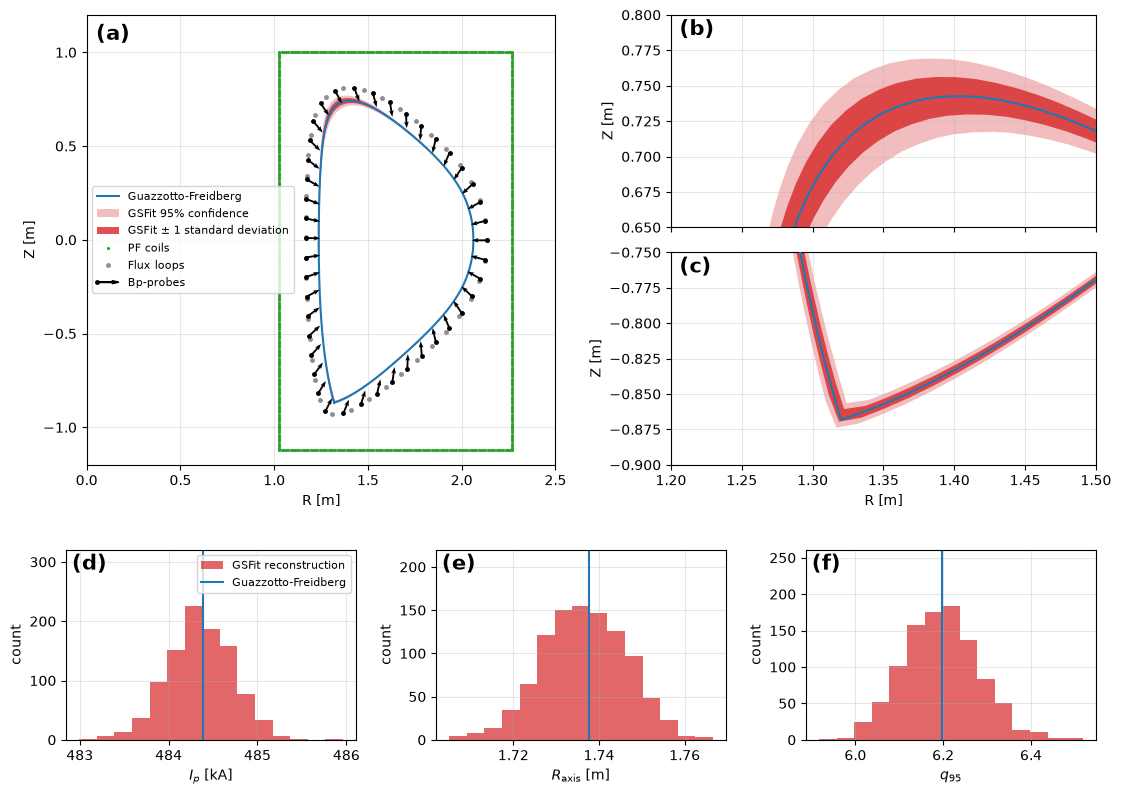

In [9]:
# --- Uncertainty in the last closed flux surface, as in example 04 ---
# Rays are fired from a fixed origin, the unperturbed reconstruction's geometric axis, and each reconstructed boundary is
# measured along them. At each ray the intersections over the perturbed reconstructions are treated as a normal distribution,
# giving the +/- 1 standard deviation band and the 95% confidence interval (mean +/- 1.96 standard deviations).
n_theta = 400
theta = np.linspace(-np.pi, np.pi, n_theta)  # [radian]
origin_r = gsfit_equilibrium_ids.get(ep.time_slice[0].boundary.geometric_axis.r)  # [metre]
origin_z = gsfit_equilibrium_ids.get(ep.time_slice[0].boundary.geometric_axis.z)  # [metre]


def boundary_radius(
    boundary_r: npt.NDArray[np.float64],
    boundary_z: npt.NDArray[np.float64],
    origin_r: float,
    origin_z: float,
    theta: npt.NDArray[np.float64],
) -> npt.NDArray[np.float64]:
    """
    Distance from (origin_r, origin_z) to a closed boundary, along each direction `theta`.

    The boundary vertices are converted to (angle, radius) about the origin and interpolated onto `theta`, wrapping around in
    angle. This is the distance to the boundary only where the boundary is star-shaped about the origin, i.e. where each ray
    crosses it exactly once, which holds for these single-null boundaries about their geometric axis.

    :param boundary_r: Closed boundary radial positions [metre]
    :param boundary_z: Closed boundary vertical positions [metre]
    :param origin_r: Origin of the rays, radial position [metre]
    :param origin_z: Origin of the rays, vertical position [metre]
    :param theta: Ray directions, measured from the outboard midplane, anticlockwise [radian]
    :return: Distance to the boundary along each ray, shape (n_theta,) [metre]
    """
    # Drop a duplicate closing vertex so no angle is repeated
    if np.hypot(boundary_r[0] - boundary_r[-1], boundary_z[0] - boundary_z[-1]) < 1.0e-9:
        boundary_r = boundary_r[:-1]
        boundary_z = boundary_z[:-1]
    vertex_angle = np.arctan2(boundary_z - origin_z, boundary_r - origin_r)  # [radian]
    vertex_radius = np.hypot(boundary_r - origin_r, boundary_z - origin_z)  # [metre]
    i_sorted = np.argsort(vertex_angle)
    vertex_angle = vertex_angle[i_sorted]
    vertex_radius = vertex_radius[i_sorted]
    # Repeat the curve either side, so interpolation near +/- pi wraps around
    angle_wrapped = np.concatenate([vertex_angle - 2.0 * np.pi, vertex_angle, vertex_angle + 2.0 * np.pi])  # [radian]
    radius_wrapped = np.concatenate([vertex_radius, vertex_radius, vertex_radius])  # [metre]
    return np.interp(theta, angle_wrapped, radius_wrapped)


# The radius of every reconstructed boundary along each ray
slice_radius = np.full((n_slice, n_theta), np.nan)  # [metre]
for i_slice in range(n_slice):
    if slice_converged[i_slice]:
        slice_radius[i_slice, :] = boundary_radius(slice_boundary_r[i_slice], slice_boundary_z[i_slice], origin_r, origin_z, theta)
# The GF equilibrium's own boundary, the truth the reconstructions are compared with
gf_radius = boundary_radius(boundary_r, boundary_z, origin_r, origin_z, theta)  # [metre]

# Slice 0 is unperturbed, so the statistics are over slices 1 onwards
radius_mean = np.nanmean(slice_radius[1:, :], axis=0)  # [metre]
radius_sigma = np.nanstd(slice_radius[1:, :], axis=0)  # [metre]
one_sigma_inner = radius_mean - radius_sigma  # [metre]
one_sigma_outer = radius_mean + radius_sigma  # [metre]
ci_95_inner = radius_mean - 1.96 * radius_sigma  # [metre]
ci_95_outer = radius_mean + 1.96 * radius_sigma  # [metre]


def ray_to_rz(radius: npt.NDArray[np.float64]) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """(R, Z) of a radius measured along each ray [metre]"""
    return origin_r + radius * np.cos(theta), origin_z + radius * np.sin(theta)


one_sigma_inner_r, one_sigma_inner_z = ray_to_rz(one_sigma_inner)
one_sigma_outer_r, one_sigma_outer_z = ray_to_rz(one_sigma_outer)
ci_95_inner_r, ci_95_inner_z = ray_to_rz(ci_95_inner)
ci_95_outer_r, ci_95_outer_z = ray_to_rz(ci_95_outer)

# --- Where the boundary is least well determined ---
i_theta_outboard = int(np.argmin(np.abs(theta)))
i_theta_inboard = int(np.argmin(np.abs(np.abs(theta) - np.pi)))
i_theta_xpt = int(np.argmin(np.abs(theta - np.arctan2(xpt_z - origin_z, xpt_r - origin_r))))
print(f"LCFS standard deviation: mean over the boundary = {1.0e3 * np.mean(radius_sigma):.2f} mm, largest = {1.0e3 * np.max(radius_sigma):.2f} mm")
print(f"   outboard midplane = {1.0e3 * radius_sigma[i_theta_outboard]:.2f} mm;  inboard midplane = {1.0e3 * radius_sigma[i_theta_inboard]:.2f} mm;  towards the X-point = {1.0e3 * radius_sigma[i_theta_xpt]:.2f} mm")
# The reconstructions are biased if the mean boundary sits away from the GF boundary by more than the standard error of the mean
bias = radius_mean - gf_radius  # [metre]
print(f"mean reconstructed boundary minus the GF boundary: mean = {1.0e3 * np.mean(bias):+.2f} mm, largest |bias| = {1.0e3 * np.max(np.abs(bias)):.2f} mm (standard error of the mean ~ {1.0e3 * np.mean(radius_sigma) / np.sqrt(n_perturbed_equilibria):.2f} mm)")

# --- What the sensor-position uncertainty does to the global quantities ---
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrow

# Each is read from every reconstructed slice; slice 0 is the unperturbed reconstruction, and the GF equilibrium is the truth.
# Each entry builds its IDS path for a given time-slice, so the same quantity can be read from every slice
global_quantities = [
    ("ip [kA]", lambda i_slice: ep.time_slice[i_slice].global_quantities.ip, 1.0e-3),
    ("magnetic axis R [mm]", lambda i_slice: ep.time_slice[i_slice].global_quantities.magnetic_axis.r, 1.0e3),
    ("magnetic axis Z [mm]", lambda i_slice: ep.time_slice[i_slice].global_quantities.magnetic_axis.z, 1.0e3),
    ("q_95", lambda i_slice: ep.time_slice[i_slice].global_quantities.q_95, 1.0),
    ("beta_pol", lambda i_slice: ep.time_slice[i_slice].global_quantities.beta_pol, 1.0),
    ("li_3", lambda i_slice: ep.time_slice[i_slice].global_quantities.li_3, 1.0),
    ("volume [m^3]", lambda i_slice: ep.time_slice[i_slice].global_quantities.volume, 1.0),
]

print("                              GF     unperturbed      mean     std dev    95% CI half-width")
global_quantity_gf = {}
global_quantity_samples = {}
for quantity_name, quantity_path, scale in global_quantities:
    gf_value = scale * gf_equilibrium_ids.get(quantity_path(0))
    samples = np.full(n_slice, np.nan)
    for i_slice in range(n_slice):
        if slice_converged[i_slice]:
            samples[i_slice] = scale * gsfit_equilibrium_ids.get(quantity_path(i_slice))
    global_quantity_gf[quantity_name] = gf_value
    global_quantity_samples[quantity_name] = samples
    perturbed = samples[1:]
    print(
        f"{quantity_name:22s} {gf_value:10.4f} {samples[0]:12.4f} {np.nanmean(perturbed):11.4f} {np.nanstd(perturbed):10.4f} {1.96 * np.nanstd(perturbed):16.4f}"
    )

# --- Figure: the confidence bands on the boundary, the two corners where they are widest, and the global quantities ---
# (a) is the whole boundary, with the fitted PF coils and the sensors at their nominal positions; (b) and (c) are the
# upper maximum and the X-point, over windows of the same size so that the two are directly comparable; (d) to (f) are
# the spread of the perturbed reconstructions in three global quantities.
zoom_windows = [
    (0.0, 2.5, coil_z.min() - 0.04, coil_z.max() + 0.04),
    (1.20, 1.50, 0.65, 0.80),
    (1.20, 1.50, -0.90, -0.75),
]
histogram_quantities = ["ip [kA]", "magnetic axis R [mm]", "q_95"]
histogram_labels = ["$I_p$ [kA]", "$R_\\mathrm{axis}$ [m]", "$q_{95}$"]
histogram_scales = [1.0, 1.0e-3, 1.0]  # from the units of the table above to the units of the axis label
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

# The (R, Z) panels are all drawn to the same scale, so each box has the shape of its own window. The boxes are placed
# by hand, in inches, so that (a) is exactly as tall as (b) and (c) together; the figure is then as wide as they need.
margin_left = 0.78  # room for (a)'s Z axis [inch]
margin_right = 0.10  # [inch]
margin_bottom = 0.45  # room for the R axis and the histograms' axis [inch]
margin_top = 0.12  # [inch]
gap_column = 0.95  # room for the zooms' Z axis [inch]
gap_row = 0.25  # (b) shares (c)'s R axis, so the two sit close together [inch]
gap_section = 0.85  # between the (R, Z) panels and the histograms [inch]
gap_histogram = 0.80  # room for each histogram's count axis [inch]
boundary_height = 4.5  # the height of (a), and of (b) and (c) together [inch]
histogram_height = 1.9  # [inch]
figure_height = margin_bottom + histogram_height + gap_section + boundary_height + margin_top  # [inch]
width_full = boundary_height * (zoom_windows[0][1] - zoom_windows[0][0]) / (zoom_windows[0][3] - zoom_windows[0][2])  # [inch]
width_zoom = (boundary_height - gap_row) * (zoom_windows[1][1] - zoom_windows[1][0]) / (
    (zoom_windows[1][3] - zoom_windows[1][2]) + (zoom_windows[2][3] - zoom_windows[2][2])
)  # [inch]
height_upper_maximum = width_zoom * (zoom_windows[1][3] - zoom_windows[1][2]) / (zoom_windows[1][1] - zoom_windows[1][0])  # [inch]
height_xpt = width_zoom * (zoom_windows[2][3] - zoom_windows[2][2]) / (zoom_windows[2][1] - zoom_windows[2][0])  # [inch]
figure_width = margin_left + width_full + gap_column + width_zoom + margin_right  # [inch]
width_histogram = (figure_width - margin_left - margin_right - 2.0 * gap_histogram) / 3.0  # [inch]
boundary_bottom = margin_bottom + histogram_height + gap_section  # [inch]
zoom_left = margin_left + width_full + gap_column  # [inch]
fig = plt.figure(figsize=(figure_width, figure_height))
ax_full = fig.add_axes((margin_left / figure_width, boundary_bottom / figure_height, width_full / figure_width, boundary_height / figure_height))
ax_xpt = fig.add_axes((zoom_left / figure_width, boundary_bottom / figure_height, width_zoom / figure_width, height_xpt / figure_height))
ax_upper_maximum = fig.add_axes(
    (
        zoom_left / figure_width,
        (boundary_bottom + height_xpt + gap_row) / figure_height,
        width_zoom / figure_width,
        height_upper_maximum / figure_height,
    )
)
ax_histogram = [
    fig.add_axes(
        (
            (margin_left + i_histogram * (width_histogram + gap_histogram)) / figure_width,
            margin_bottom / figure_height,
            width_histogram / figure_width,
            histogram_height / figure_height,
        )
    )
    for i_histogram in range(3)
]

for i_panel, ax_panel in enumerate([ax_full, ax_upper_maximum, ax_xpt]):
    # The analytic boundary is drawn first so that it leads the legend, and `zorder` keeps it on top of the bands
    ax_panel.plot(boundary_r, boundary_z, color="tab:blue", lw=1.5, zorder=3, label="Guazzotto-Freidberg")
    ax_panel.fill(
        np.concatenate([ci_95_inner_r, np.flip(ci_95_outer_r)]),
        np.concatenate([ci_95_inner_z, np.flip(ci_95_outer_z)]),
        color="tab:red",
        alpha=0.3,
        linewidth=0.0,
        zorder=1,
        label="GSFit 95% confidence",
    )
    ax_panel.fill(
        np.concatenate([one_sigma_inner_r, np.flip(one_sigma_outer_r)]),
        np.concatenate([one_sigma_inner_z, np.flip(one_sigma_outer_z)]),
        color="tab:red",
        alpha=0.8,
        linewidth=0.0,
        zorder=2,
        label="GSFit $\\pm$ 1 standard deviation",
    )
    (zoom_r_min, zoom_r_max, zoom_z_min, zoom_z_max) = zoom_windows[i_panel]
    ax_panel.set_xlim(zoom_r_min, zoom_r_max)
    ax_panel.set_ylim(zoom_z_min, zoom_z_max)
    # The boxes above already have the shape of their window; this only guards the scale if that arithmetic is ever changed
    ax_panel.set_aspect("equal")
    ax_panel.grid(True, alpha=0.3)
    ax_panel.set_ylabel("Z [m]")
    ax_panel.text(0.02, 0.98, panel_labels[i_panel], transform=ax_panel.transAxes, fontsize=15, fontweight="bold", ha="left", va="top")

# (b) covers the same R range as (c) and sits directly above it, so it does not need its own R axis
ax_upper_maximum.tick_params(labelbottom=False)
ax_full.set_xlabel("R [m]")
ax_xpt.set_xlabel("R [m]")

# The fitted PF coils, one single filament per node of the analytic grid's boundary, and the magnetic sensors at their
# nominal positions, which is where the reconstruction believes them to be. Each BP probe carries an arrow along the
# field component it measures, which here is towards the magnetic axis.
sensor_marker_size = 2.5  # [point]
ax_full.plot(coil_r, coil_z, ".", color="tab:green", markersize=2.5, zorder=4, label="PF coils")
ax_full.plot(flux_loop_r, flux_loop_z, "o", color="#8F8F8F", markersize=sensor_marker_size, zorder=4, label="Flux loops")
ax_full.plot(bp_probe_r, bp_probe_z, "o", color="k", markersize=sensor_marker_size, zorder=4)
ax_full.quiver(bp_probe_r, bp_probe_z, np.cos(bp_probe_angle), np.sin(bp_probe_angle), color="k", scale=32.0, width=0.004, headwidth=2.5, headlength=3.5, headaxislength=3.0, zorder=4)
ax_full.set_ylim(-1.2, 1.2)


class HandlerBpProbe(HandlerBase):
    """The BP probe legend entry: the dot and the arrow they are drawn with in (a), which no default handler draws"""

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        arrow = FancyArrow(0.0, 0.5 * height, width, 0.0, width=0.5, head_width=0.4 * height, head_length=0.3 * width, length_includes_head=True, color="k")
        dot = Line2D([0.0], [0.5 * height], marker="o", color="k", markersize=sensor_marker_size, linestyle="none")
        for artist in [arrow, dot]:
            artist.set_transform(trans)
        return [arrow, dot]


# Inboard of the plasma there is nothing drawn, so the legend goes there
legend_handles, legend_labels = ax_full.get_legend_handles_labels()
legend_handles.append(FancyArrow(0.0, 0.0, 1.0, 0.0, color="k"))
legend_labels.append("Bp-probes")
ax_full.legend(legend_handles, legend_labels, loc="center left", fontsize=8, handler_map={FancyArrow: HandlerBpProbe()})

# (d) to (f): how far the perturbations move three of the global quantities, against the analytic value
for i_histogram in range(3):
    ax_panel = ax_histogram[i_histogram]
    quantity_name = histogram_quantities[i_histogram]
    scale = histogram_scales[i_histogram]
    ax_panel.hist(scale * global_quantity_samples[quantity_name][1:], bins=15, color="tab:red", alpha=0.7, label="GSFit reconstruction")
    ax_panel.axvline(scale * global_quantity_gf[quantity_name], color="tab:blue", lw=1.5, label="Guazzotto-Freidberg")
    ax_panel.set_xlabel(histogram_labels[i_histogram])
    ax_panel.set_ylabel("count")
    ax_panel.grid(True, alpha=0.3)
    # Headroom above the tallest bar, for the panel label and for (d)'s legend
    ax_panel.set_ylim(0.0, 1.35 * ax_panel.get_ylim()[1])
    ax_panel.text(0.02, 0.98, panel_labels[3 + i_histogram], transform=ax_panel.transAxes, fontsize=15, fontweight="bold", ha="left", va="top")
ax_histogram[0].legend(loc="upper right", fontsize=8)
plt.show()

fig.savefig("guazzotto_freidberg_sensor_perturbation.pdf")

# # --- The same uncertainty against poloidal angle, where the bands are too thin to see in (R, Z) ---
# # Zero is the outboard midplane, and the angle runs anticlockwise; the X-point is marked.
# theta_xpt = np.arctan2(xpt_z - origin_z, xpt_r - origin_r)  # [radian]
# fig, (ax_sigma, ax_bias) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
# ax_sigma.plot(np.rad2deg(theta), 1.0e3 * radius_sigma, color="tab:blue")
# ax_sigma.set_ylabel("standard deviation [mm]")
# ax_sigma.set_title("Uncertainty in the boundary position, along rays from the geometric axis")
# ax_bias.plot(np.rad2deg(theta), 1.0e3 * bias, color="tab:blue", label="mean reconstruction $-$ GF")
# ax_bias.plot(np.rad2deg(theta), 1.0e3 * (slice_radius[0, :] - gf_radius), color="crimson", ls="--", label="unperturbed reconstruction $-$ GF")
# ax_bias.set_xlabel("poloidal angle from the outboard midplane [degree]")
# ax_bias.set_ylabel("displacement [mm]")
# ax_bias.legend(fontsize=8)
# for ax_panel in [ax_sigma, ax_bias]:
#     ax_panel.axvline(np.rad2deg(theta_xpt), color="0.5", ls=":", lw=1.5)
#     ax_panel.annotate("X-point", (np.rad2deg(theta_xpt), ax_panel.get_ylim()[1]), fontsize=8, color="0.4", ha="center", va="top")
#     ax_panel.grid(alpha=0.3)
# fig.tight_layout()
# plt.show()